In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ptyrad.analysis import Analyzer

In [2]:
from tifffile import imread, imwrite

In [3]:
import hyperspy.api as hs

In [4]:
import colorcet as cc

In [5]:
%matplotlib widget

In [6]:
# Change this to the ABSOLUTE PATH to the ptyrad/ folder so you can correctly access data/ and params/
work_dir = '/Users/nihy/Desktop/Working Data/DRX/Zone 211/Shear Corrected/Analysis'

os.chdir(work_dir)
print("Current working dir: ", os.getcwd())
# The printed working dir should be ".../ptyrad/" to locate the example params files easily

Current working dir:  /Users/nihy/Desktop/Working Data/DRX/Zone 211/Shear Corrected/Analysis


In [7]:
model_path ='/Users/nihy/Desktop/Working Data/DRX/Zone 211/Shear Corrected/model_iter0430.hdf5'
analyzer = Analyzer(model_path)
print(analyzer)

Analyzer(source='/Users/nihy/Desktop/Working Data/DRX/Zone 211/Shear Corrected/model_iter0430.hdf5', niter=430, obj=(omode=1, nslice=26), probe=(pmode=6, shape=(256, 256)))


In [8]:
print("Top-level keys:")
for k in analyzer.data.keys():
    print(" ", k)

Top-level keys:
  avg_iter_t
  avg_losses
  avg_tilt_iters
  batch_losses
  convergence_iters
  dz_iters
  indices
  iter_times
  loss_iters
  lr_iters
  model_attributes
  niter
  optim_state_dict
  optimizable_tensors
  output_path
  params
  ptyrad_version
  random_seed
  scheduler_state_dict


In [9]:
# Full dotted-key listing of every array stored in the HDF5
print("\n".join(analyzer.get_keys()))

avg_iter_t
avg_losses.loss_pacbed
avg_losses.loss_poissn
avg_losses.loss_simlar
avg_losses.loss_single
avg_losses.loss_sparse
avg_tilt_iters.niter
avg_tilt_iters.tilt_x
avg_tilt_iters.tilt_y
batch_losses.loss_pacbed
batch_losses.loss_poissn
batch_losses.loss_simlar
batch_losses.loss_single
batch_losses.loss_sparse
convergence_iters.obja_bg
convergence_iters.obja_fg
convergence_iters.objp_bg
convergence_iters.objp_fg
convergence_iters.probe
convergence_iters.probe_pos_shifts
dz_iters
indices
iter_times
loss_iters
lr_iters.niter
lr_iters.obj_tilts
lr_iters.obja
lr_iters.objp
lr_iters.probe
lr_iters.probe_pos_shifts
model_attributes.H
model_attributes.N_scan_fast
model_attributes.N_scan_slow
model_attributes.crop_pos
model_attributes.detector_blur_std
model_attributes.dk
model_attributes.dx
model_attributes.lambd
model_attributes.lr_params.obj_tilts
model_attributes.lr_params.obja
model_attributes.lr_params.objp
model_attributes.lr_params.probe
model_attributes.lr_params.probe_pos_shifts


In [10]:
analyzer.data['params']['init_params']['pos_params']

'output_crop_quarter/20260826_full_N10000_dp256_flipT100_random64_p6_1obj_26slice_dz10/model_iter0100.hdf5'

In [11]:
analyzer.data['model_attributes']['crop_pos']

array([[272,  79],
       [271,  83],
       [268,  86],
       ...,
       [422, 615],
       [420, 618],
       [418, 621]], shape=(10000, 2), dtype=int32)

In [12]:
print(f'model_attributes:\n  {list(analyzer.model_attrs.keys())}\n')
print(f'optimizable_tensors:\n  {list(analyzer.opt_tensors.keys())}\n')
print(f'params:\n  {list(analyzer.params.keys())}\n')

model_attributes:
  ['H', 'N_scan_fast', 'N_scan_slow', 'crop_pos', 'detector_blur_std', 'dk', 'dx', 'lambd', 'lr_params', 'meas_Npix', 'omode_occu', 'probe_int_sum', 'scan_affine', 'simu_Npix', 'simu_match_mode', 'slice_thickness', 'start_iter', 'tilt_obj']

optimizable_tensors:
  ['obj_tilts', 'obja', 'objp', 'probe', 'probe_pos_shifts', 'slice_thickness']

params:
  ['constraint_params', 'hypertune_params', 'init_params', 'loss_params', 'model_params', 'params_path', 'recon_params']



In [13]:
# Convenient scalar properties derived from model_attributes and optimizable_tensors
print(f"Real-space pixel size  dx    = {analyzer.dx:.4f} Å")
print(f"Probe modes  pmode           = {analyzer.pmode}")
print(f"Object modes omode           = {analyzer.omode}")
print(f"Z-slices     nslice          = {analyzer.nslice}")
print(f"Multislice?                  = {analyzer.is_multislice}")
print(f"Saved at iteration           = {analyzer.niter}")

Real-space pixel size  dx    = 0.1277 Å
Probe modes  pmode           = 6
Object modes omode           = 1
Z-slices     nslice          = 26
Multislice?                  = True
Saved at iteration           = 430


In [14]:
#analyzer.plot_dashboard()

In [15]:
obja = analyzer.get_object_amplitude(fov='crop')
objp = analyzer.get_object_phase(fov='crop')
print("Object shape (omode, Nz, Ny, Nx):", obja.shape)

Object shape (omode, Nz, Ny, Nx): (1, 26, 535, 543)


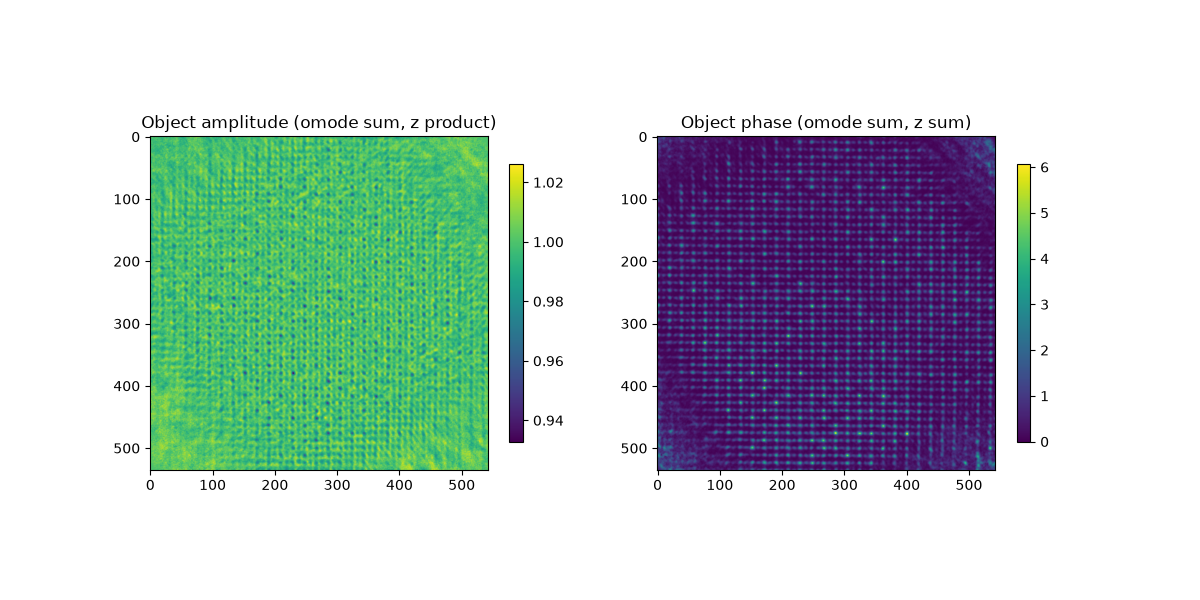

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
im0 = axs[0].imshow(obja.sum(0).prod(0))
im1 = axs[1].imshow(objp.sum(0).sum(0))
fig.colorbar(im0, shrink=0.6)
fig.colorbar(im1, shrink=0.6)
axs[0].set_title('Object amplitude (omode sum, z product)')
axs[1].set_title('Object phase (omode sum, z sum)')
plt.show()
# Amplitude is multiplicative along depth (transmission product); phase is additive (phase sum).

In [17]:
pos = analyzer.get_probe_positions(target='crop')
print("Positions shape (N_scan, 2) [y, x]:", pos.shape)

Positions shape (N_scan, 2) [y, x]: (10000, 2)


In [18]:
help(analyzer.get_probe_positions)

Help on method get_probe_positions in module ptyrad.analysis.analyzer:

get_probe_positions(
    fov: Literal['full', 'crop'] = 'full',
    *,
    target: Literal['probe', 'crop'] = 'probe',
    units: Literal['px', 'pixel', 'Ang'] = 'px',
    include_sub_px_shifts: bool = True,
    as_torch: bool = False,
    device: str = 'cpu'
) method of ptyrad.analysis.analyzer.Analyzer instance
    Probe-center or crop-window positions; see :func:`extract.extract_probe_positions`.

    ``include_sub_px_shifts`` controls whether the optimized
    ``probe_pos_shifts`` offsets are included. ``target='probe'`` returns
    probe centers; ``target='crop'`` returns crop-window top-left
    positions, which can be negative when combined with ``fov='crop'``.

    Power users who hold only a sub-dict (e.g. just
    ``optimizable_tensors`` from a streaming loader) should call the
    standalone :func:`extract.extract_probe_positions` with explicit
    ``model_attrs``.



In [19]:
c = np.arange(10000)
s = np.arange(10000)*1e-3

/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_80453/3292146028.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pos[:, 0], pos[:, 1], s = 3, color = 'tomato', label = 'After Optimization', cmap = 'Reds')


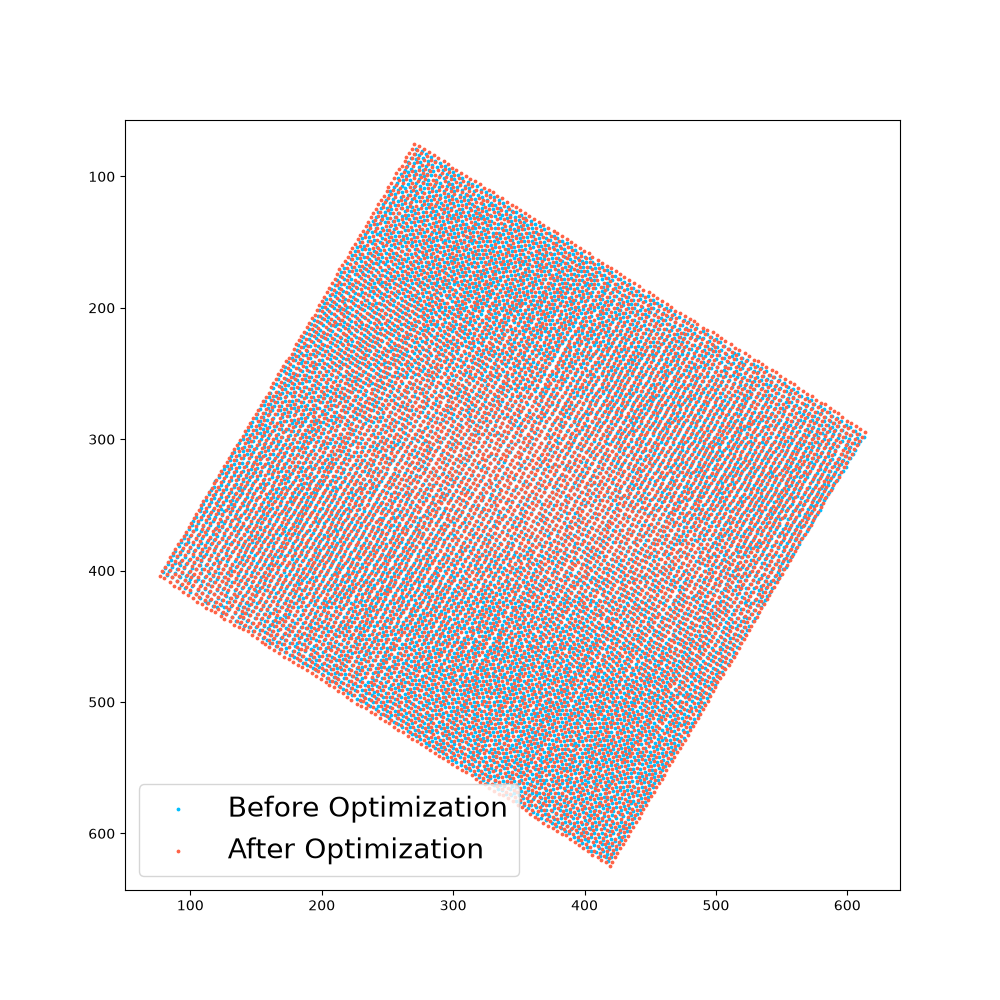

In [20]:
plt.figure(figsize = (10, 10))
plt.scatter(analyzer.data['model_attributes']['crop_pos'][:, 0], analyzer.data['model_attributes']['crop_pos'][:, 1], s = 3, color = 'deepskyblue', label = 'Before Optimization')
plt.scatter(pos[:, 0], pos[:, 1], s = 3, color = 'tomato', label = 'After Optimization', cmap = 'Reds')
#plt.quiver(analyzer.data['model_attributes']['crop_pos'][:, 0], 
#           analyzer.data['model_attributes']['crop_pos'][:, 1], 
#           pos[:, 0]-analyzer.data['model_attributes']['crop_pos'][:, 0], 
#           pos[:, 1]-analyzer.data['model_attributes']['crop_pos'][:, 1], 
#           angles='xy', scale_units='xy', scale=0.2, color='k', alpha=1, label = 'Displacement', pivot = 'middle')
plt.axis('equal')
plt.gca().invert_yaxis()
plt.legend(fontsize = 20)
plt.savefig(os.path.join(work_dir, 'probe_positions.png'), dpi = 300)

In [21]:
displacement = pos - analyzer.data['model_attributes']['crop_pos']
np.linalg.norm(displacement, axis=1).mean()*0.2630,np.linalg.norm(displacement, axis=1).max()*0.2630

(np.float64(0.5425556410673582), np.float64(1.237296993894589))

In [22]:
imwrite(os.path.join(work_dir,"object_amplitude.tif"), obja.sum(0).astype(np.float32))
imwrite(os.path.join(work_dir,"object_phase.tif"), objp.sum(0).astype(np.float32))

In [23]:
probe = analyzer.get_probe(space='real')
print("Probe shape (pmode, Ny, Nx):", probe.shape)

Probe shape (pmode, Ny, Nx): (6, 256, 256)


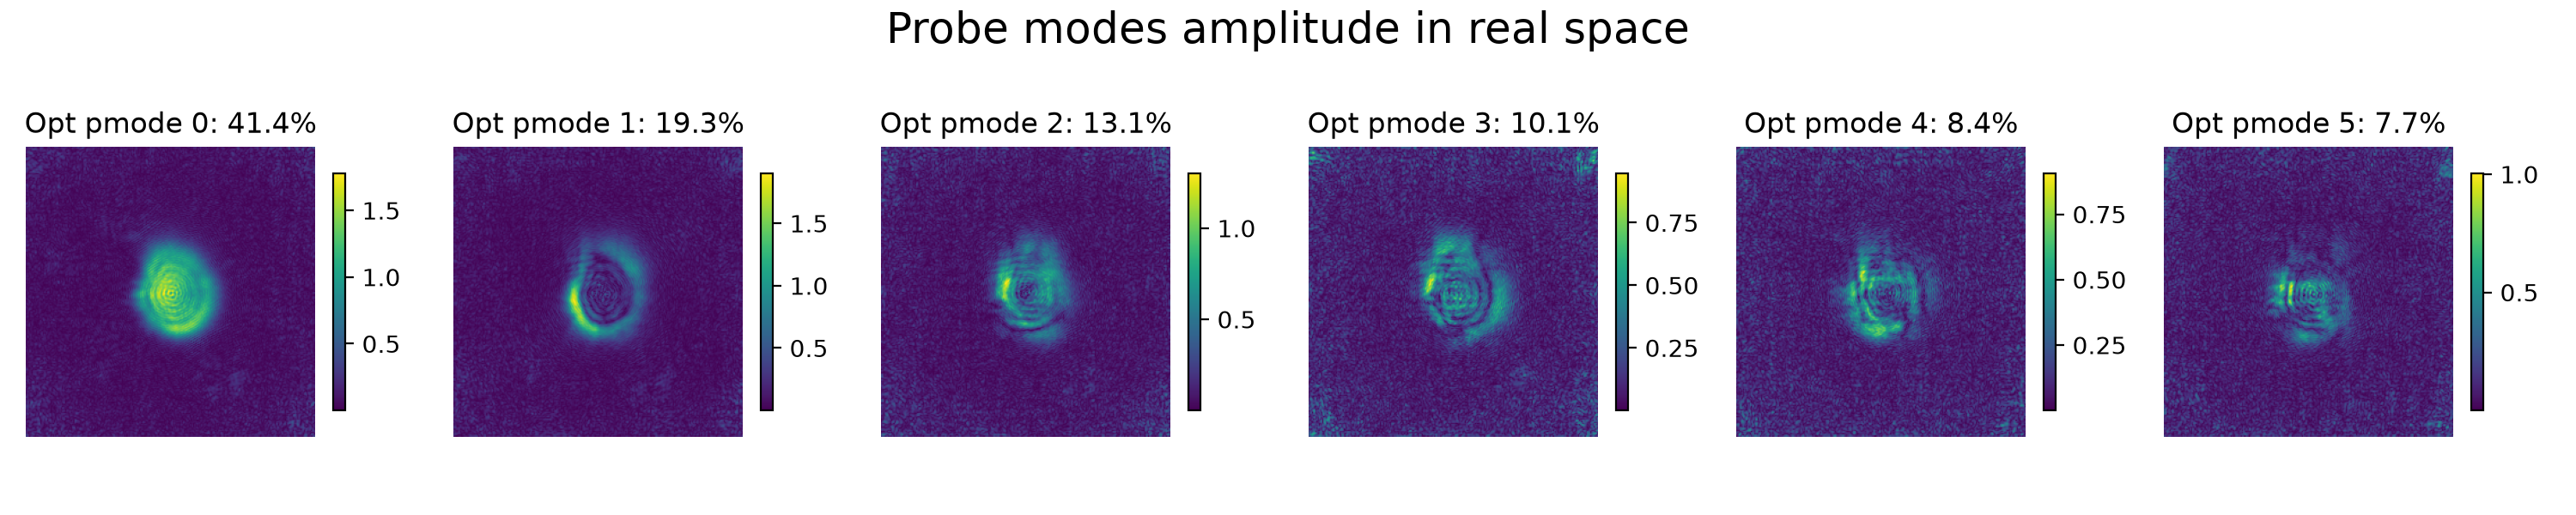

In [24]:
analyzer.plot_probe(space='real',    amp_or_phase='amplitude')

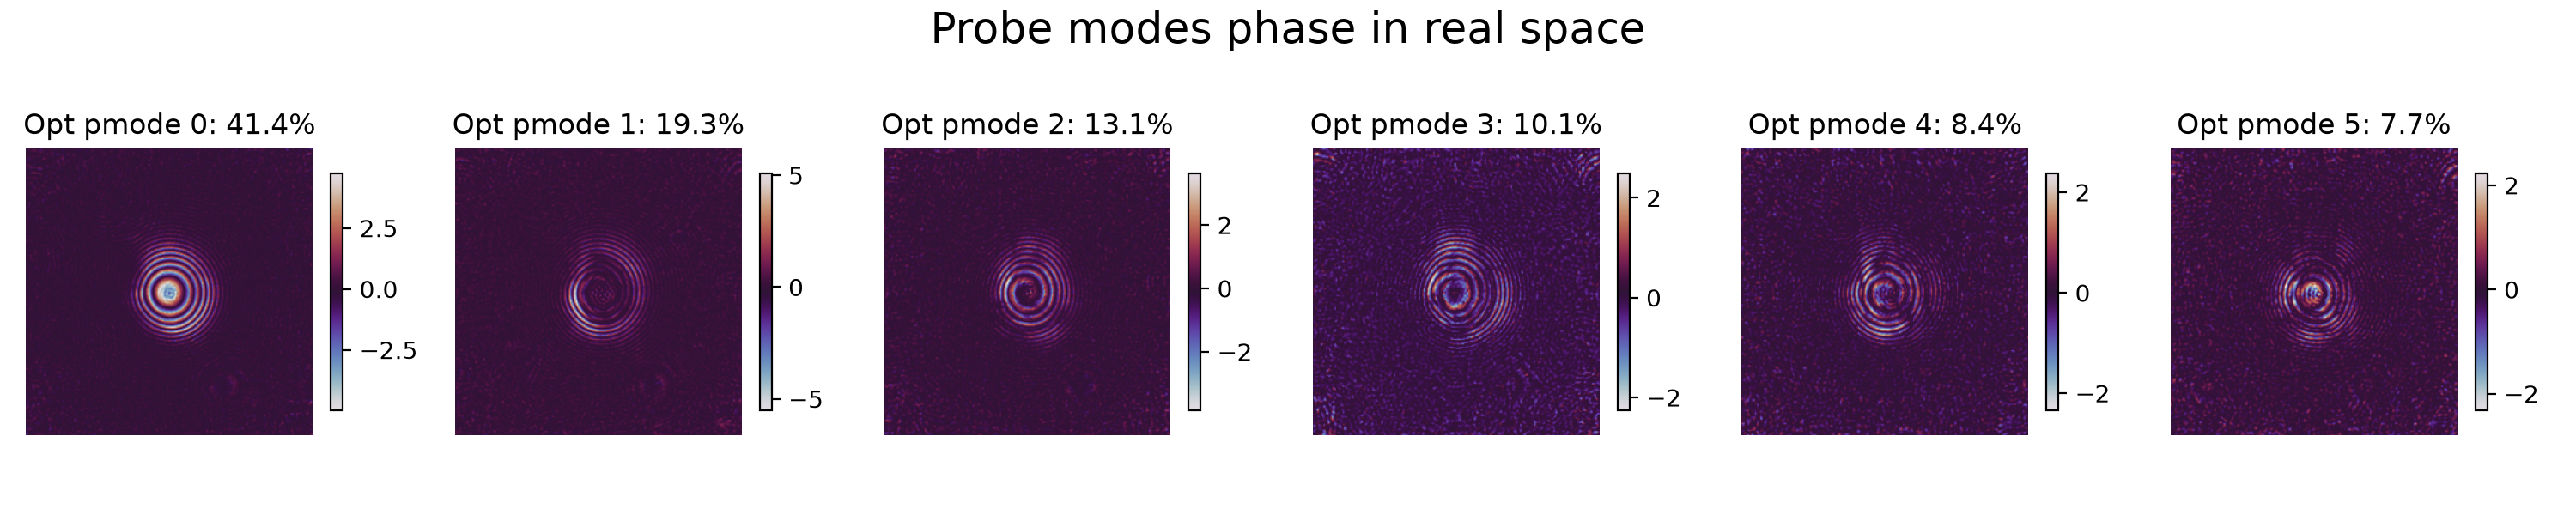

In [25]:
analyzer.plot_probe(space='real',    amp_or_phase='phase')